# Alberth std-filtered to SAM3

這個 notebook 複用 `Alberth_pipeline.ipynb` 到 `std_filtered_vid[segment == 0.0] = 0.0`，
接著做 `robust_scale(std_filtered_vid, 1, 99.99)`，再把結果輸出成 JPEG frame 序列，最後直接在 notebook 內測試本地 `SAM3` 的文字提示輸入。

In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from transformers import Sam3Model, Sam3Processor

repo_root = Path.cwd().resolve().parents[1] if Path.cwd().name == "Schlieren" else Path.cwd().resolve().parent if Path.cwd().name == "examples" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

try:
    import cupy as _cupy  # type: ignore
    _cupy.cuda.runtime.getDeviceCount()
    cp = _cupy
    USING_CUPY = True
except Exception as exc:
    print(f"CuPy unavailable, falling back to NumPy backend: {exc}")
    USING_CUPY = False

    class _NumpyCompat:
        def __getattr__(self, name):
            return getattr(np, name)

        def asarray(self, a, dtype=None):
            return np.asarray(a, dtype=dtype)

        def asnumpy(self, a):
            return np.asarray(a)

    cp = _NumpyCompat()  # type: ignore

from OSCC_postprocessing.cine.functions_videos import load_cine_video
from OSCC_postprocessing.filters.stdfilt import stdfilt
from OSCC_postprocessing.io.async_avi_saver import AsyncAVISaver
from OSCC_postprocessing.utils.scaling import robust_scale

if USING_CUPY:
    from OSCC_postprocessing.rotation.rotate_with_alignment import (
        rotate_video_nozzle_at_0_half_cupy as rotate_video_nozzle_at_0_half_backend,
    )
else:
    from OSCC_postprocessing.rotation.rotate_with_alignment_cpu import (
        rotate_video_nozzle_at_0_half_numpy as rotate_video_nozzle_at_0_half_backend,
    )


def to_numpy(arr):
    return cp.asnumpy(arr) if USING_CUPY else np.asarray(arr)


def export_jpeg_frames(video_u8: np.ndarray, output_dir: Path, jpeg_quality: int = 95) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    params = [int(cv2.IMWRITE_JPEG_QUALITY), int(jpeg_quality)]
    for idx, frame in enumerate(video_u8):
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        frame_path = output_dir / f"{idx:05d}.jpg"
        ok = cv2.imwrite(str(frame_path), frame_bgr, params)
        if not ok:
            raise RuntimeError(f"Failed to write JPEG frame: {frame_path}")


def export_mjpg_avi(video_u8: np.ndarray, output_path: Path, fps: int = 30) -> None:
    video_bgr = np.repeat(video_u8[..., None], 3, axis=-1)
    saver = AsyncAVISaver(max_workers=1, default_codec="MJPG")
    try:
        saver.save(output_path, video_bgr, fps=fps, codec="MJPG", is_color=True, auto_normalize=False)
        saver.wait()
    finally:
        saver.shutdown(wait=False)


c:\Users\Jiang\Documents\Mie_Postprocessing_Py\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file = Path(r"G:\MeOH_test\Schlieren\T55_Schlieren Cam_3.cine")
json_file = Path(r"G:\MeOH_test\Schlieren\config.json")
out_dir = Path(r"G:\MeOH_test\Schlieren\Processed_Results")

video_bits = 12
std_filt_ksize = 21
jpeg_quality = 95
fps = 30
frame_limit = None

sam3_model_dir = repo_root / ".models" / "sam3_hf"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"repo_root: {repo_root}")
print(f"device: {device}")
print(f"sam3_model_dir exists: {sam3_model_dir.exists()} -> {sam3_model_dir}")

repo_root: C:\Users\Jiang\Documents\Mie_Postprocessing_Py
device: cuda
sam3_model_dir exists: True -> C:\Users\Jiang\Documents\Mie_Postprocessing_Py\.models\sam3_hf


In [3]:
brightness_levels = float(2**video_bits)
video = load_cine_video(str(file), frame_limit=frame_limit).astype(np.float32) / brightness_levels
F, H, W = video.shape

with open(json_file, "r", encoding="utf-8") as handle:
    data = json.load(handle)
    offset = float(data["offset"])
    centre = (float(data["centre_x"]), float(data["centre_y"]))

print(f"video shape: {video.shape}")
print(f"offset: {offset}")
print(f"centre: {centre}")

Video Info - Width: 768, Height: 768, Frames: 401
video shape: (401, 768, 768)
offset: -45.0
centre: (191.0, 108.0)


In [4]:
out_shape = (H // 2, H)

segment, _, _ = rotate_video_nozzle_at_0_half_backend(
    video,
    centre,
    offset,
    interpolation="nearest",
    border_mode="constant",
    out_shape=out_shape,
)

segment = cp.asarray(robust_scale(segment, 1, 99.9), dtype=cp.float32)
print(f"segment shape: {tuple(int(v) for v in segment.shape)}")

segment shape: (401, 384, 768)


In [5]:
std_filtered_vid = stdfilt(segment, ksize=std_filt_ksize)
std_filtered_vid[segment == 0.0] = 0.0

std_filtered_normalized = cp.asarray(robust_scale(std_filtered_vid, 1, 99.99), dtype=cp.float32)
std_filtered_normalized_np = to_numpy(std_filtered_normalized).astype(np.float32, copy=False)
std_filtered_normalized_u8 = (std_filtered_normalized_np * 255.0).round().astype(np.uint8)

experiment_root = out_dir / f"{file.stem}_std_filtered_jpeg"
jpeg_dir = experiment_root / "jpeg_frames"
npy_path = experiment_root / "std_filtered_normalized.npy"
avi_path = experiment_root / "std_filtered_normalized_mjpg.avi"
experiment_root.mkdir(parents=True, exist_ok=True)

np.save(npy_path, std_filtered_normalized_np)
export_jpeg_frames(std_filtered_normalized_u8, jpeg_dir, jpeg_quality=jpeg_quality)
export_mjpg_avi(std_filtered_normalized_u8, avi_path, fps=fps)

print(f"saved numpy: {npy_path}")
print(f"saved jpeg frames for SAM3: {jpeg_dir}")
print(f"saved mjpg avi: {avi_path}")

saved numpy: G:\MeOH_test\Schlieren\Processed_Results\T55_Schlieren Cam_3_std_filtered_jpeg\std_filtered_normalized.npy
saved jpeg frames: G:\MeOH_test\Schlieren\Processed_Results\T55_Schlieren Cam_3_std_filtered_jpeg\jpeg_frames
saved mjpg avi: G:\MeOH_test\Schlieren\Processed_Results\T55_Schlieren Cam_3_std_filtered_jpeg\std_filtered_normalized_mjpg.avi


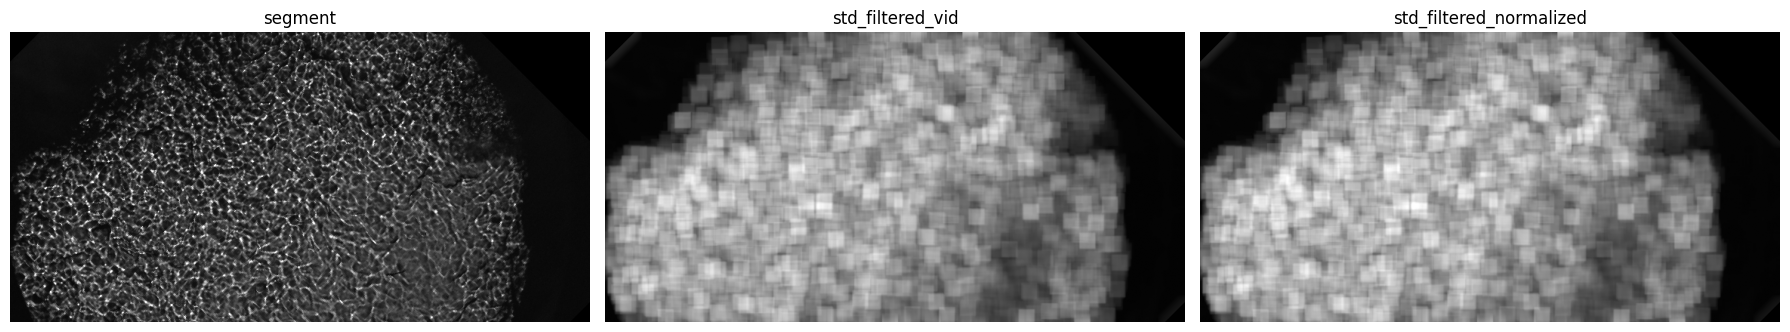

In [6]:
frame_idx = 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(to_numpy(segment[frame_idx]), cmap="gray")
axes[0].set_title("segment")
axes[1].imshow(to_numpy(std_filtered_vid[frame_idx]), cmap="gray")
axes[1].set_title("std_filtered_vid")
axes[2].imshow(std_filtered_normalized_np[frame_idx], cmap="gray", vmin=0.0, vmax=1.0)
axes[2].set_title("std_filtered_normalized")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## SAM3 prompt試驗

下面先把 `std_filtered_normalized` 的單幀轉成偽 RGB，再交給 `SAM3` image API。
這裡先測文字提示詞，後面如果效果差，再改成 box / point / mask prompt。

In [7]:
model = Sam3Model.from_pretrained(sam3_model_dir).to(device)
processor = Sam3Processor.from_pretrained(sam3_model_dir)
print("SAM3 loaded")

Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 11468.68it/s]


SAM3 loaded


In [8]:
frame_idx = 0
prompt = "spray"

frame_u8 = std_filtered_normalized_u8[frame_idx]
frame_rgb = np.repeat(frame_u8[..., None], 3, axis=-1)
sam3_image = Image.fromarray(frame_rgb, mode="RGB")


def run_sam3_text_prompt(image: Image.Image, text_prompt: str, threshold: float = 0.5, mask_threshold: float = 0.5):
    inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=threshold,
        mask_threshold=mask_threshold,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]
    return results


results = run_sam3_text_prompt(sam3_image, prompt)
print(f"prompt: {prompt}")
print(f"detections: {len(results['masks'])}")
results

prompt: spray
detections: 0


{'scores': tensor([], device='cuda:0'),
 'boxes': tensor([], device='cuda:0', size=(0, 4)),
 'masks': tensor([], device='cuda:0', size=(0, 288, 288), dtype=torch.int64)}

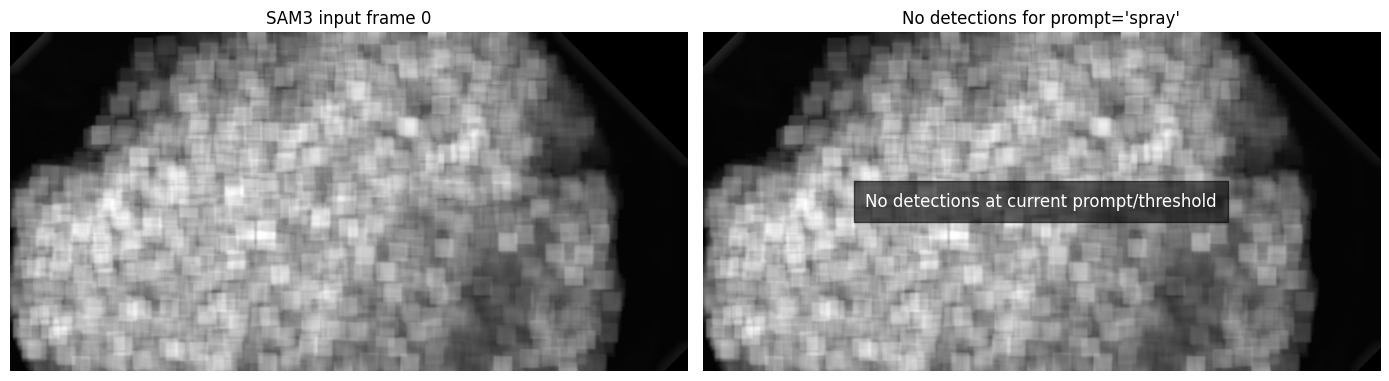

In [9]:
from matplotlib.patches import Rectangle

img = np.array(sam3_image)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img)
axes[0].set_title(f"SAM3 input frame {frame_idx}")
axes[0].axis("off")

axes[1].imshow(img)
num_masks = len(results["masks"])
if num_masks == 0:
    axes[1].set_title(f"No detections for prompt='{prompt}'")
    axes[1].text(
        0.5,
        0.5,
        "No detections at current prompt/threshold",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
        color="white",
        fontsize=12,
        bbox=dict(facecolor="black", alpha=0.6, pad=8),
    )
else:
    colors = plt.cm.tab10(np.linspace(0, 1, num_masks))
    for mask, box, score, color in zip(results["masks"], results["boxes"], results["scores"], colors):
        mask_np = mask.detach().cpu().numpy().astype(bool)
        color_rgb = np.array(color[:3])
        overlay = np.zeros((*mask_np.shape, 4), dtype=np.float32)
        overlay[mask_np, :3] = color_rgb
        overlay[mask_np, 3] = 0.35
        axes[1].imshow(overlay)
        x0, y0, x1, y1 = box.detach().cpu().tolist()
        axes[1].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=color_rgb, linewidth=2))
        axes[1].text(
            x0,
            max(y0 - 6, 0),
            f"score={float(score):.3f}",
            color="white",
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.6, pad=2),
        )
    axes[1].set_title(f"SAM3 detections for prompt='{prompt}'")

axes[1].axis("off")
plt.tight_layout()
plt.show()

In [10]:
candidate_prompts = [
    "spray",
    "jet plume",
    "foreground plume",
    "fluid jet",
    "smoke plume",
    "dark foreground object",
]

prompt_summary = []
for text_prompt in candidate_prompts:
    prompt_results = run_sam3_text_prompt(sam3_image, text_prompt)
    prompt_summary.append(
        {
            "prompt": text_prompt,
            "detections": int(len(prompt_results["masks"])),
            "scores": [float(v) for v in prompt_results["scores"].detach().cpu().tolist()],
        }
    )

prompt_summary

[{'prompt': 'spray', 'detections': 0, 'scores': []},
 {'prompt': 'jet plume', 'detections': 0, 'scores': []},
 {'prompt': 'foreground plume', 'detections': 0, 'scores': []},
 {'prompt': 'fluid jet', 'detections': 0, 'scores': []},
 {'prompt': 'smoke plume', 'detections': 0, 'scores': []},
 {'prompt': 'dark foreground object', 'detections': 0, 'scores': []}]